<a href="https://colab.research.google.com/github/dyarparvar/scRNA-to-Clinic/blob/main/module1_scrna_foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1: Single-Cell RNA-seq Foundations

---

### What this notebook teaches

By the end, we will have run a complete scRNA-seq analysis pipeline — the same type of analysis we would do on kidney or lung tissue from CKD/respiratory disease patients.

We use the real PBMC 3k dataset from 10x Genomics together with synthetic CKD patient data.

---

### The big picture — what is scRNA-seq actually measuring?

Every cell in the body has the same DNA. What makes a T cell different from a macrophage is **which genes are switched on** (transcribed into RNA).

Single-cell RNA sequencing captures, for each individual cell:
- Which genes are active
- How active they are

From this, we can:
1. **Cluster** cells into types (T cells, B cells, NK cells, monocytes...)
2. **Compare** healthy vs. diseased cells
3. **Find** genes that define a disease state → drug targets

---

### The pipeline — 6 steps

```
Raw data → Quality Control → Normalisation → Feature Selection
        → Dimensionality Reduction → Clustering → Annotation
```

---
## Step 0: Setup and data loading

In [ ]:
# Clone the GitHub repo
import os
from getpass import getpass

os.chdir('/content')

REPO_OWNER = "dyarparvar"
REPO_NAME = "scRNA-to-Clinic"

user_email = "d.yarparvar@email.com"
user_name = "dyarparvar"
os.system(f"git config --global user.email '{user_email}'")
os.system(f"git config --global user.name '{user_name}'")

token = getpass("Enter your GitHub token: ")

repo_url = f"https://{token}@github.com/{REPO_OWNER}/{REPO_NAME}.git"

!git clone {repo_url}

In [72]:
# Navigate to the repo
%cd /content/scRNA-to-Clinic/
!git status
# Set the parent directory to the repo root directory
PARENT_DIR = os.getcwd()
print(f"\n Parent directory: {PARENT_DIR}")

/content/scRNA-to-Clinic
On branch main
Your branch is ahead of 'origin/main' by 3 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean

 Parent directory: /content/scRNA-to-Clinic


In [73]:
!pip install --quiet scanpy

In [74]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sc.settings.set_figure_params(dpi=80, facecolor='white')

print('Libraries loaded successfully')

Libraries loaded successfully


In [75]:
# Load the real PBMC 3k dataset (healthy) from 10x Genomics
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()


print(adata)
print(f'\nThis is our data matrix: {adata.n_obs} cells × {adata.n_vars} genes')

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

This is our data matrix: 2700 cells × 32738 genes


To create some synthetic Chronic Kidney Disease (CKD) data while preserving the complex, messy, real-world background noise of an actual human sequencing run, we can use a semi-synthetic simulation.

We can take the real pbmc3k data, designate half of the cells asdiseased, and then manually alter the underlying sparse matrix to inject an explicit, realistic inflammatory signal into the cells assigned to the CKD group.

In [76]:
# Assign the condition split (50% real Healthy, 50% designated for synthetic CKD)
np.random.seed(42)
adata.obs['condition'] = np.random.choice(['Healthy', 'CKD'], size=adata.n_obs)

# Define the target genes
# Upregulated: Inflammatory drivers
up_genes = ['IL1B', 'CCL2', 'TNF']
# Downregulated: Antigen presentation (MHC Class II)
down_genes = ['HLA-DRA', 'CD74']

# Filter to ensure they exist in the dataset
available_up = [g for g in up_genes if g in adata.var_names]
available_down = [g for g in down_genes if g in adata.var_names]

# Inject the synthetic disease signal into the sparse matrix
# Because adata.X is a compressed sparse matrix, modifying elements directly is
# computationally inefficient. We convert it temporarily to List-of-Lists (LIL) format.
X_lil = adata.X.tolil()

# Isolate the row indices of the cells assigned to the CKD group
ckd_indices = np.where(adata.obs['condition'] == 'CKD')[0]

# Inject Upregulation (Inflammatory burst)
for gene in available_up:
    gene_idx = adata.var_names.get_loc(gene)
    count_boost = np.random.poisson(lam=6, size=len(ckd_indices))
    for i, cell_idx in enumerate(ckd_indices):
        X_lil[cell_idx, gene_idx] += count_boost[i]

# Inject Downregulation (Immune exhaustion)
for gene in available_down:
    gene_idx = adata.var_names.get_loc(gene)
    for cell_idx in ckd_indices:
        current_val = X_lil[cell_idx, gene_idx]
        if current_val > 0:
            # Suppress expression by 90% to simulate transcriptional shut-down
            X_lil[cell_idx, gene_idx] = int(current_val * 0.1)

# Convert back to the standard, highly efficient Compressed Sparse Row format
adata.X = X_lil.tocsr()

print("\nSemi-synthetic matrix preparation complete.")
print(f"Total cells retained: {adata.n_obs}")
print(f"Upregulated disease targets: {available_up}")
print(f"Downregulated (exhausted) targets: {available_down}")


Semi-synthetic matrix preparation complete.
Total cells retained: 2700
Upregulated disease targets: ['IL1B', 'CCL2', 'TNF']
Downregulated (exhausted) targets: ['HLA-DRA', 'CD74']


### Understanding the `adata` object

**AnnData** is the core data structure in Scanpy. Think of it as a smart spreadsheet:

- **`adata.X`** — the main matrix: rows = cells, columns = genes. Values = RNA count per gene per cell.
- **`adata.obs`** — a DataFrame with one row per cell. Stores metadata: patient ID, condition, QC metrics.
- **`adata.var`** — a DataFrame with one row per gene. Stores gene metadata: is it mitochondrial? is it highly variable?
- **`adata.obsm`** — stores embeddings like PCA coordinates and UMAP coordinates.

Everything lives in one object. When we pass `adata` to any Scanpy function, it reads from and writes back into this same object.

In [77]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2289496 stored elements and shape (2700, 32738)>

In [78]:
adata.obs

,condition
index,
AAACATACAACCAC-1,Healthy
AAACATTGAGCTAC-1,CKD
AAACATTGATCAGC-1,Healthy
AAACCGTGCTTCCG-1,Healthy
AAACCGTGTATGCG-1,Healthy
...,...
TTTCGAACTCTCAT-1,CKD
TTTCTACTGAGGCA-1,CKD
TTTCTACTTCCTCG-1,CKD


In [79]:
adata.var

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945
...,...
AC145205.1,ENSG00000215635
BAGE5,ENSG00000268590
CU459201.1,ENSG00000251180


In [80]:
adata.obsm

AxisArrays with keys: 

In [81]:
# Look at the raw count matrix — first 5 cells, first 8 genes
# Most values are small integers (RNA molecule counts)

raw_df = pd.DataFrame(
    adata.X[:5, :8].toarray(),
    index=adata.obs_names[:5],
    columns=adata.var_names[:8]
)
print('Raw count matrix (first 5 cells, first 8 genes):')
print(raw_df.astype(int))

Raw count matrix (first 5 cells, first 8 genes):
index             MIR1302-10  FAM138A  OR4F5  RP11-34P13.7  RP11-34P13.8  \
index                                                                      
AAACATACAACCAC-1           0        0      0             0             0   
AAACATTGAGCTAC-1           0        0      0             0             0   
AAACATTGATCAGC-1           0        0      0             0             0   
AAACCGTGCTTCCG-1           0        0      0             0             0   
AAACCGTGTATGCG-1           0        0      0             0             0   

index             AL627309.1  RP11-34P13.14  RP11-34P13.9  
index                                                      
AAACATACAACCAC-1           0              0             0  
AAACATTGAGCTAC-1           0              0             0  
AAACATTGATCAGC-1           0              0             0  
AAACCGTGCTTCCG-1           0              0             0  
AAACCGTGTATGCG-1           0              0             0 

---
## Step 1: Quality Control (QC)

Not every "cell" in the data is actually a healthy, intact cell:

1. **Empty droplets** — microfluidic droplet captured ambient RNA but no cell → very few genes detected
2. **Doublets** — two cells captured in one droplet → suspiciously many genes
3. **Dead/dying cells** — stressed or broken cells lose cytoplasm, retaining mitochondrial RNA → high % mitochondrial counts

### The three QC metrics:
- `n_genes_by_counts` — how many distinct genes were detected in the cell
- `total_counts` — total RNA molecules detected (library size)
- `pct_counts_mt` — what % of counts come from mitochondrial genes (MT- prefix)

In [82]:
# Mark mitochondrial genes (start with 'MT-' in human)
adata.var['mt'] = adata.var_names.str.startswith('MT-')

print(f'Mitochondrial genes in our dataset: {adata.var["mt"].sum()}')
print('They are:', adata.var_names[adata.var['mt']].tolist())

Mitochondrial genes in our dataset: 13
They are: ['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB']


`sc.pp.calculate_qc_metrics` computes fundamental statistics about the cells and genes.

`percent_top=None`: By default, this function calculates the percentage of total molecular counts accounted for by the top 50, 100, 200, and 500 most highly expressed genes in each cell. Setting it to None explicitly disables this calculation. This is a smart move to save computational time and memory if we do not plan on using those specific top-tier metrics for the filtering strategy.

`log1p=False`: This stops the function from applying a log(1+x) transformation to the counts before calculating the metrics. We almost always want to calculate the QC metrics on the raw, unnormalised molecular counts, so ensuring this is set to False is best practice.

After running the following code, we will see several new columns have appeared in adata.obs, most notably:
- n_genes_by_counts: The number of genes expressed in each cell.
- total_counts: The total number of RNA molecules (UMIs) detected in each cell.
- pct_counts_mt: The percentage of a cell's total counts that originate from mitochondrial genes.

In [83]:
# Calculate QC metrics — this adds columns to adata.obs
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print('QC metrics added to adata.obs:')
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe().round(1))

QC metrics added to adata.obs:
       n_genes_by_counts  total_counts  pct_counts_mt
count             2700.0        2700.0         2700.0
mean               848.0        2368.9            2.2
std                282.1        1087.1            1.2
min                215.0         555.0            0.0
25%                691.0        1757.8            1.5
50%                818.0        2207.0            2.0
75%                954.0        2765.2            2.6
max               3424.0       15668.0           22.6


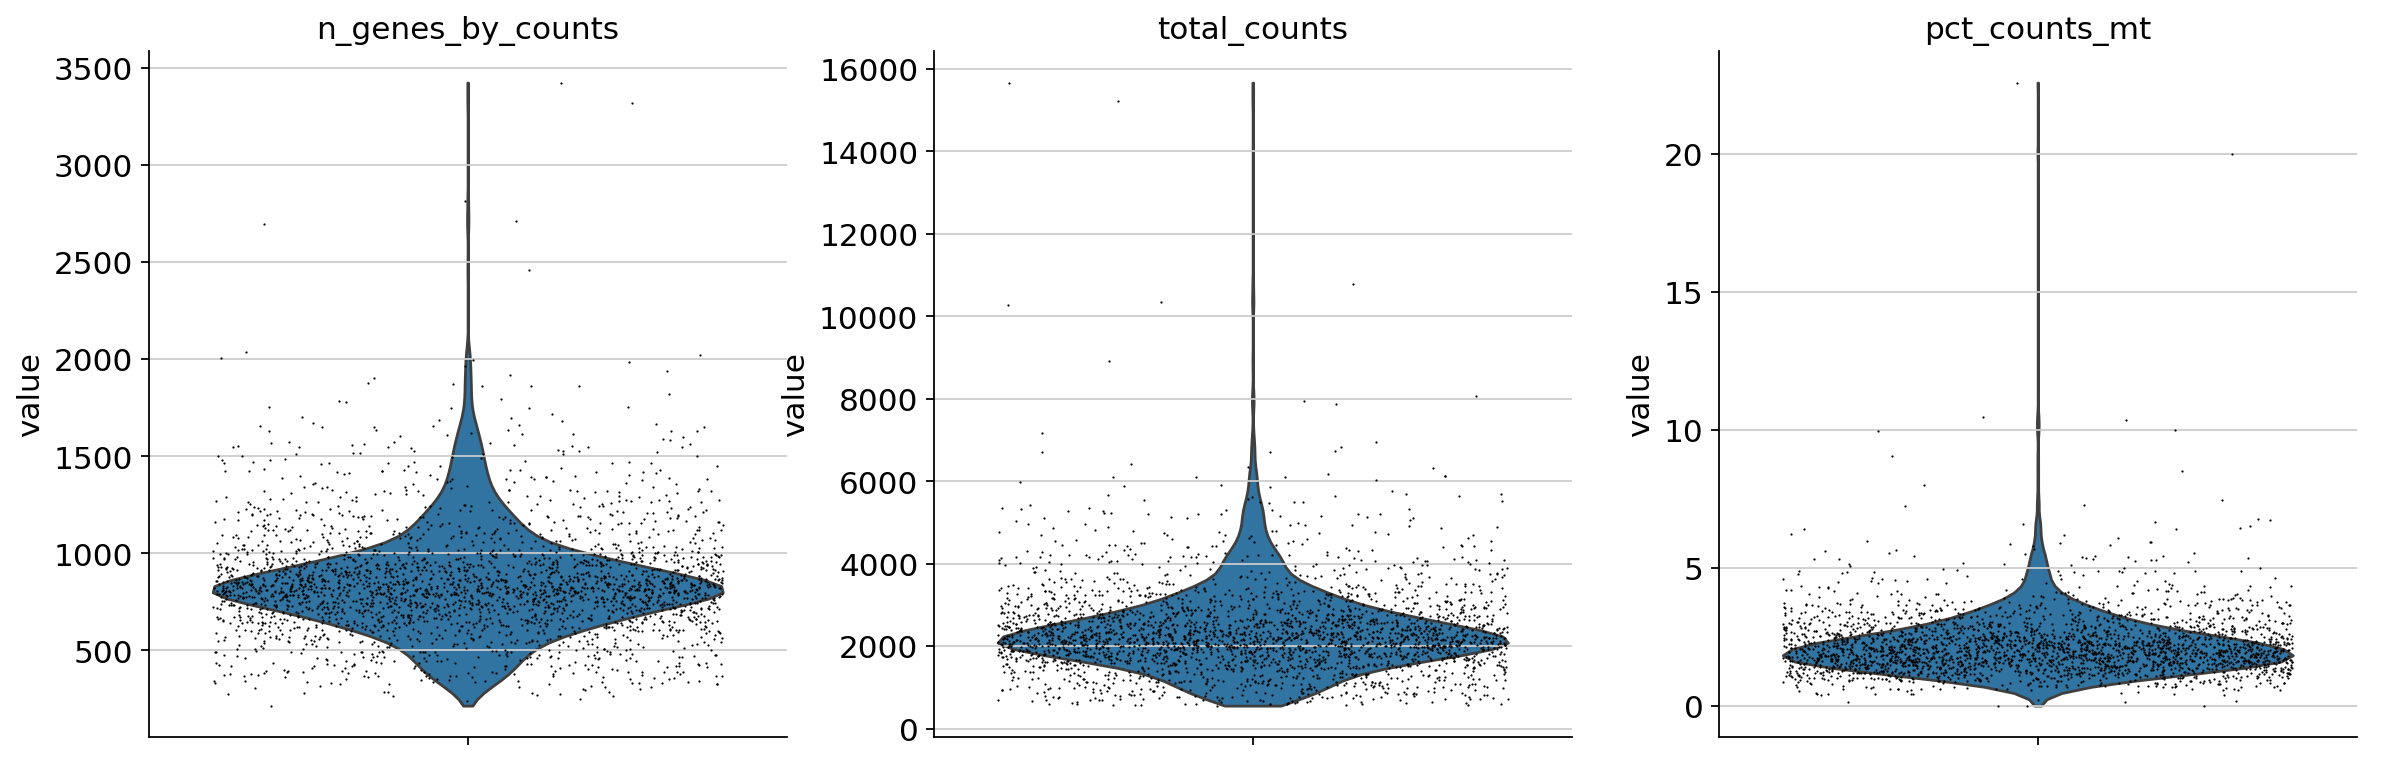

In [84]:
# Visualise QC metrics — this exact plot appears in every scRNA-seq paper
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True
)

### Reading the QC violin plots

- **n_genes_by_counts**: The bulk of cells sit in a healthy range. Any outliers far above (doublets?) or below (empty droplets?) need removing.
- **total_counts**: Similar — most cells clustered together, outliers suspicious.
- **pct_counts_mt**: Healthy cells have low mt%. The spike at the top = dying cells.




If a gene is only detected in a single cell, it is highly improbable that this represents a robust, biologically meaningful signal. Instead, it is almost certainly a technical artefact. These artefacts can arise from:
- Sequencing errors: A misread barcode mapping to the wrong gene.
- Ambient RNA: RNA floating in the background solution that accidentally got encapsulated in a droplet.

By demanding a minimum presence of 3 cells, we are ensuring a baseline level of reproducibility for every gene in the catalogue.

**Noise genes**: Genes that are not detected in at least three distinct cells across the entire dataset → should be removed



Now we filter:

In [85]:
print(f'Cells BEFORE QC filtering: {adata.n_obs}')

sc.pp.filter_cells(adata, min_genes=50)          # remove empty droplets
sc.pp.filter_genes(adata, min_cells=3)           # remove noise genes
adata = adata[adata.obs.pct_counts_mt < 20].copy()  # remove dying cells

print(f'Cells AFTER QC filtering:  {adata.n_obs}')
print(f'Genes AFTER QC filtering:  {adata.n_vars}')
print(f'\nWe removed {500 - adata.n_obs} low-quality cells.')

Cells BEFORE QC filtering: 2700
Cells AFTER QC filtering:  2698
Genes AFTER QC filtering:  13714

We removed -2198 low-quality cells.


---
## Step 2: Normalisation

### The problem

Different cells were sequenced at different depths — one cell might have 1,000 total RNA counts, another 5,000. This is **technical noise**, not biology. A gene in the deep-sequenced cell will always look higher in raw counts even if it's expressed at the same level.

### What we do:
1. **Library size normalisation**: Scale every cell to the same total count (10,000 by convention)
2. **Log-transform**: `log(x + 1)` to compress the dynamic range — a gene going from 1→100 counts isn't 100x more biologically important. Log transformation accurately reflects the biological reality of diminishing returns: the initial jump from 0 to a few transcripts is a massive biological event, whereas adding more transcripts to an already saturated system is biologically trivial.  
PCA, in the next step, is "variance greedy". If we do not compress the dynamic range, the "megastar" genes with thousands of counts will completely dominate the variance and subtle changes will be completely ignored.

In [86]:
# Save the raw counts before transforming (good practice — we may need them later)
adata.layers['counts'] = adata.X.copy()

# Step 1: The industry-standard "Counts Per Ten Thousand" (CP10k) normalisation
sc.pp.normalize_total(adata, target_sum=1e4)

# Step 2: The standard natural log transformation (log(x + 1))
sc.pp.log1p(adata)

# Save normalised values (a permanent snapshot)
adata.layers['normalised'] = adata.X.copy()

print('Normalisation complete.')
print('adata.layers:', list(adata.layers.keys()))

Normalisation complete.
adata.layers: ['counts', 'normalised']


---
## Step 3: Feature Selection — Highly Variable Genes (HVGs)

### Why?

Most genes are **housekeeping genes** — expressed at the same level in every cell (ribosomes, metabolism). They carry no information about cell identity.

We keep only the **top 2,000 most variable genes** — the ones whose expression differs most across cells. These are the genes that actually distinguish cell types.

This also speeds up computation enormously.

`flavor='seurat'`: This specifies the underlying mathematical model used to calculate variability. The 'seurat' flavour (named after the popular R package) calculates the dispersion (variance divided by mean) for each gene.

By default, highly expressed genes naturally have higher variance. The Seurat method corrects for this by fitting a trend line across all genes. It then selects genes that have a much higher variance than expected for their specific mean expression level.

Highly variable genes selected: 2000




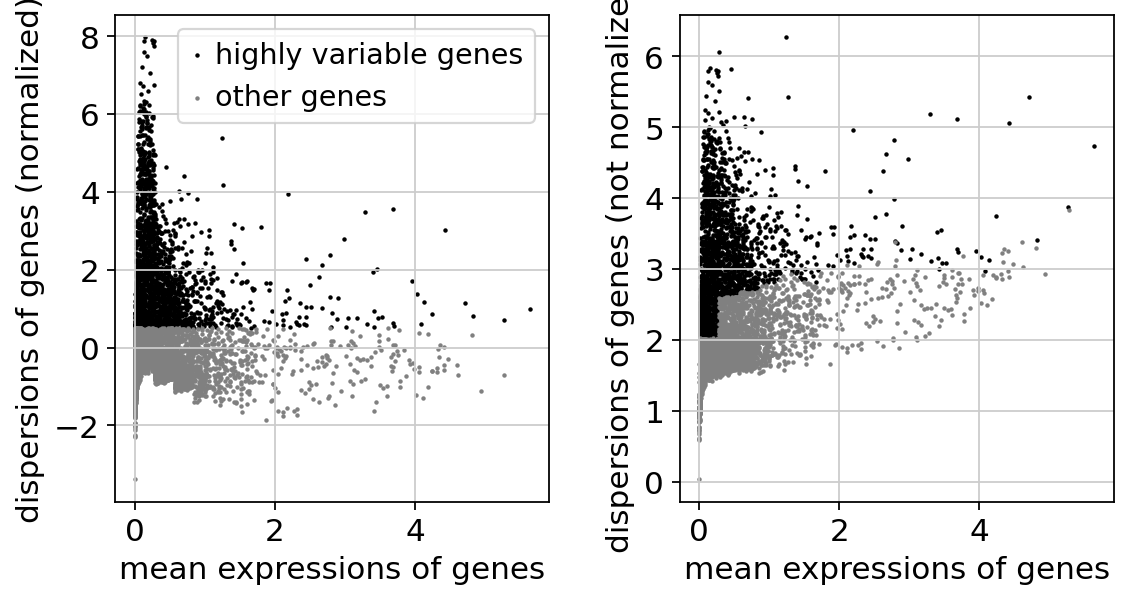

In [87]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat')

print(f'Highly variable genes selected: {adata.var.highly_variable.sum()}\n\n')

sc.pl.highly_variable_genes(adata)

### Reading the HVG plot

- **X-axis**: mean expression of the gene across all cells
- **Y-axis**: how variable that gene is
- **Orange dots**: selected as highly variable

Notice the real marker genes (CD3E, CD19, CD14 etc.) tend to be selected — they're variable because only certain cell types express them.

In [88]:
# Which of our known marker genes were selected as HVGs?
marker_genes = ['CD3E', 'CD4', 'CD8A', 'CD19', 'MS4A1', 'GNLY', 'CD14', 'LYZ']
for g in marker_genes:
    if g in adata.var_names:
        selected = adata.var.loc[g, 'highly_variable']
        print(f'{g}: {"✓ selected" if selected else "not selected"}')

CD3E: not selected
CD4: not selected
CD8A: not selected
CD19: ✓ selected
MS4A1: ✓ selected
GNLY: ✓ selected
CD14: not selected
LYZ: ✓ selected


In [89]:
# Freeze the full normalised matrix before subsetting
adata.raw = adata

# Scanpy's PCA algorithm is smart enough to look for the 'highly_variable'
# column automatically. It will use the 2,000 genes to build the map,
# but leave all genes in the matrix for the Wilcoxon test later.
# adata = adata[:, adata.var.highly_variable].copy()

print(f'Working matrix: {adata.n_obs} cells × {adata.n_vars} genes')

Working matrix: 2698 cells × 13714 genes


---
## Step 4: Dimensionality Reduction — PCA

We have 2000 genes × 2698 cells. Still too high-dimensional to cluster efficiently.

**PCA** finds the directions of maximum variance and projects each cell onto them. We go from 2000 dimensions → 100 principal components, keeping most of the signal.

Because true biological signals (like a group of 50 genes turning on together to define a T cell) create massive, coordinated variance, PCA captures them in the first 10 to 50 principal components.

PCA preserves global structure → fantastic at capturing broad, linear relationships (e.g., separating completely different lineages, like lymphoid cells from myeloid cells)

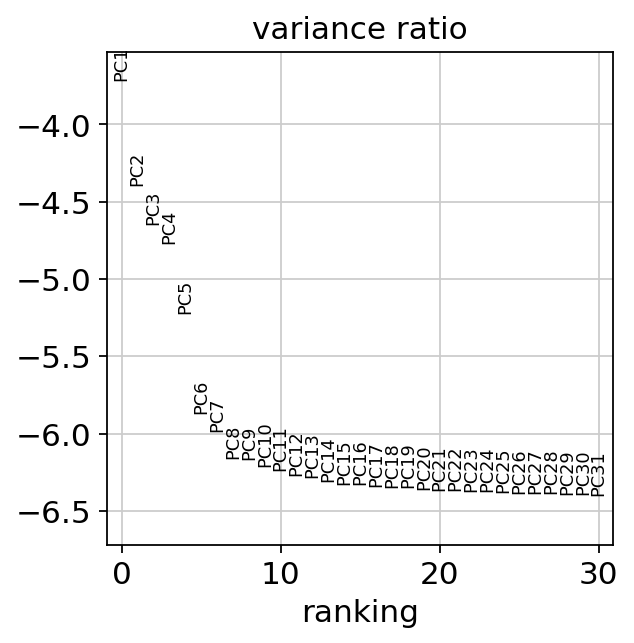

In [90]:
# Scale genes to zero mean and unit variance
# (so highly-expressed genes don't dominate PCA just due to magnitude)
sc.pp.scale(adata, max_value=10)

# Run PCA
sc.tl.pca(adata, svd_solver='arpack')

# The elbow plot: where does variance explained flatten out?
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=30)

### Reading the elbow plot

The variance explained drops steeply then flattens — the "elbow". PCs after the elbow add noise, not signal. We'll use 10 PCs downstream.

---
## Step 5: Neighbourhood Graph + UMAP

Two steps:

1. **Neighbourhood graph**: For each cell, find its K nearest neighbours in PCA space. Cells that are transcriptionally similar get connected. `sc.pp.neighbors`

2. **UMAP**: A 2D layout of that graph. Similar cells cluster together visually. `sc.tl.umap`

**Critical point**: Without PCA UMAP tries to calculate distances across thousands of axes of pure noise, diluting the true biological signals. By running UMAP on the PCA output, we are handing UMAP a beautifully clean, noise-filtered map of the data.

UMAP is for *visualisation only*. Never over-interpret UMAP distances between clusters.

UMAP preserves local structure → excels at non-linear warping to show fine-grained sub-clusters (e.g., separating helper T cells from cytotoxic T cells)

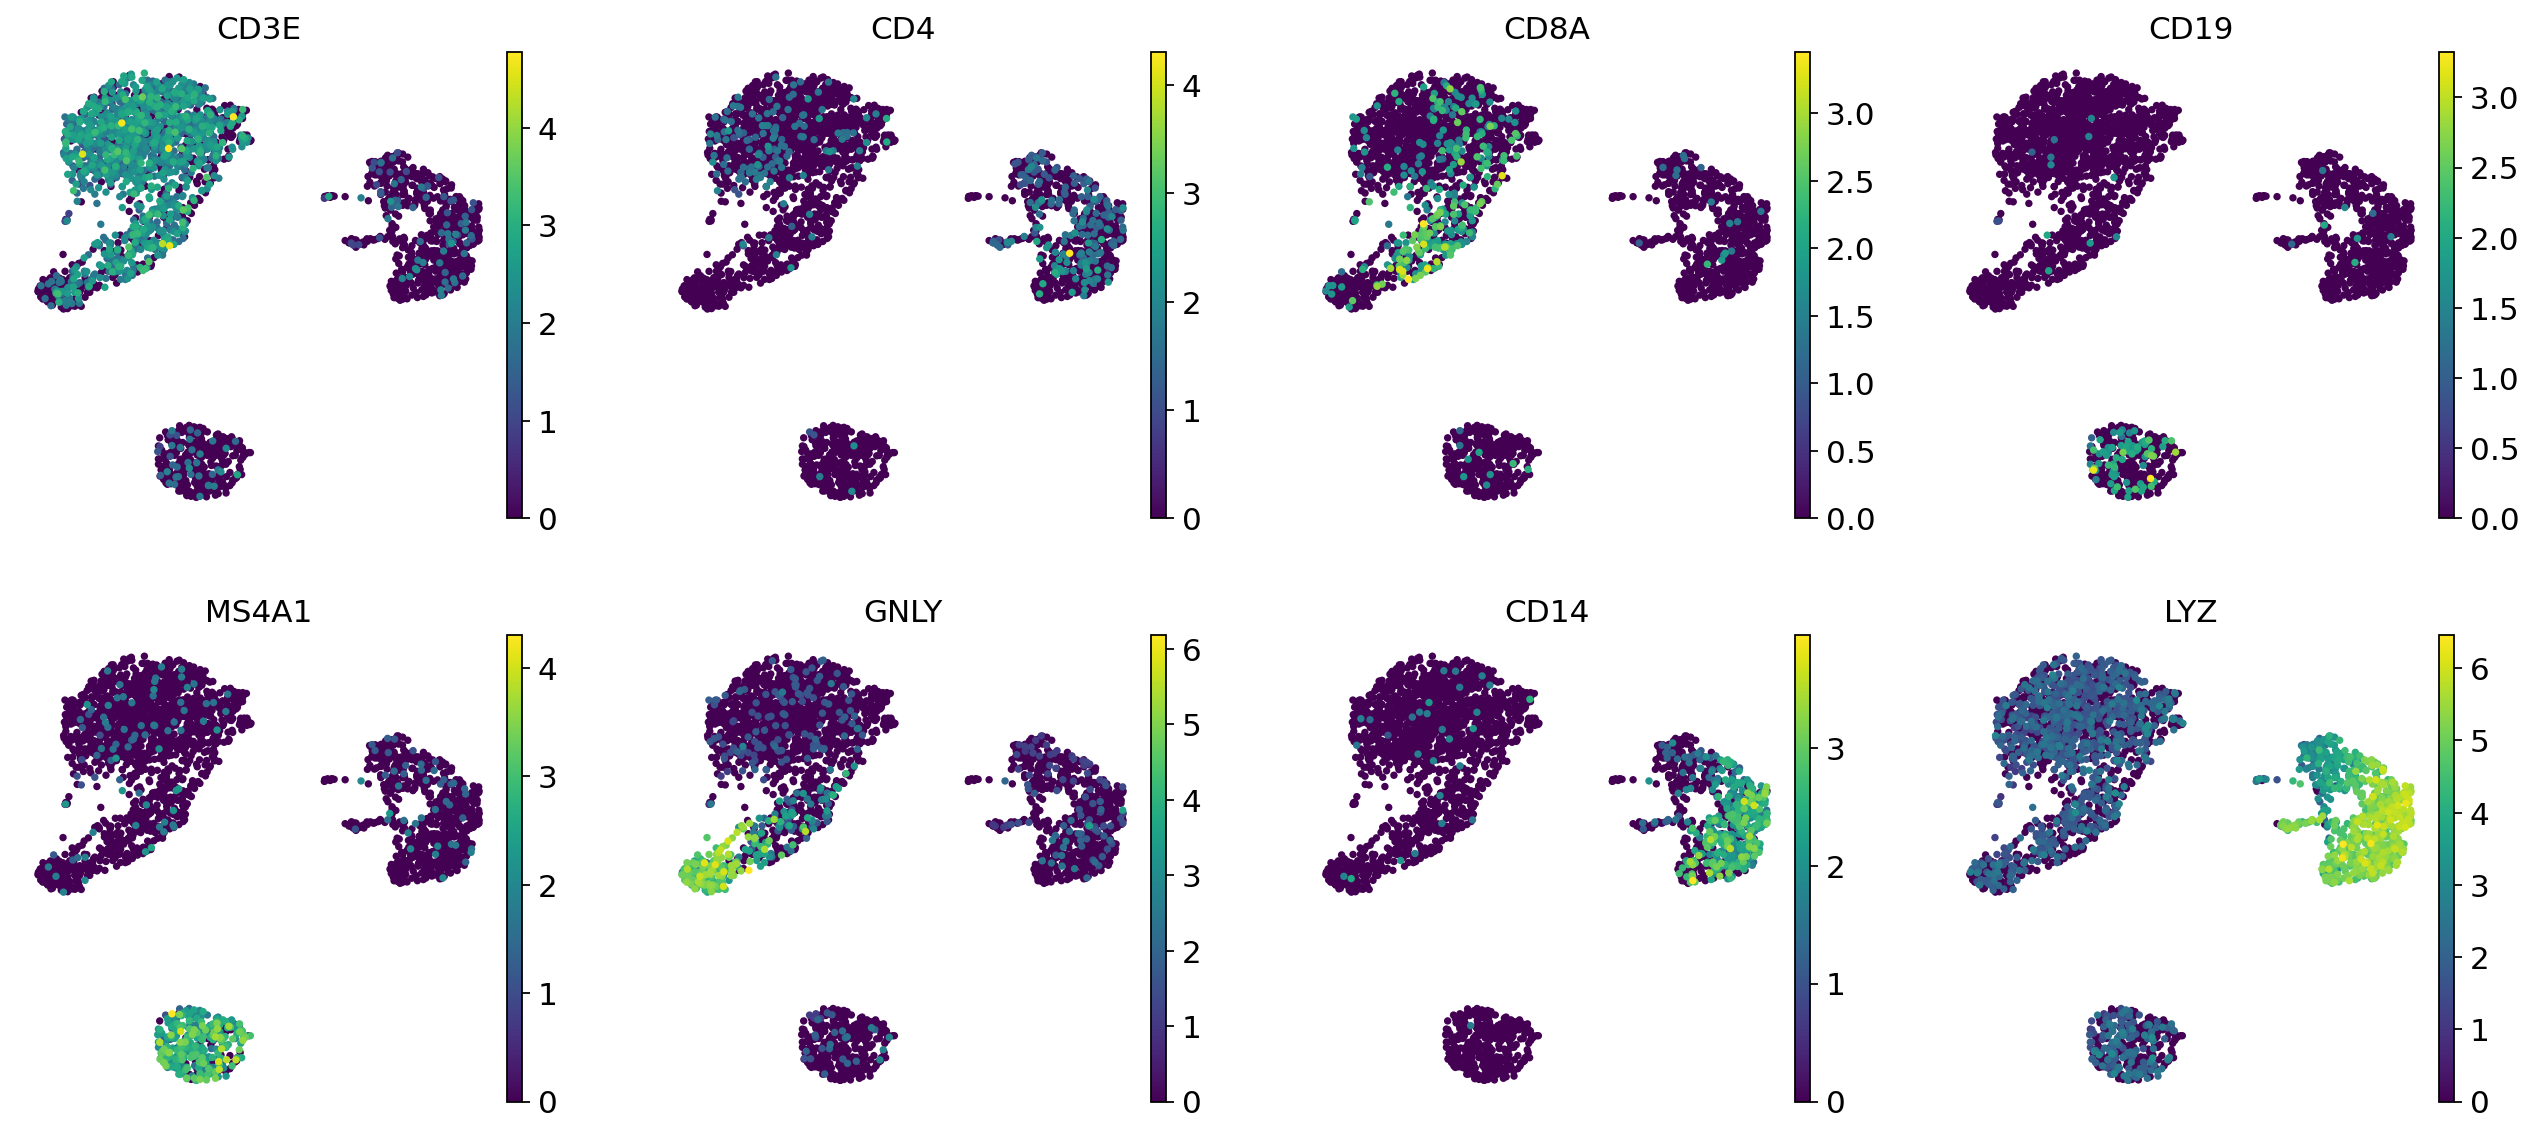

In [91]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)    # Computes the mathematical distances (Preprocessing)
sc.tl.umap(adata)   # Calculates the 2D coordinates (Tool)

# Draws the 2D UMAP plot (Plot)
sc.pl.umap(
    adata,
    color=marker_genes,
    title=marker_genes,
    ncols=4,
    frameon=False
)

### What we should see

The differnet cell types should form distinct islands in the UMAP. This confirms the pipeline is working — cells with similar transcriptomes (same cell type, same marker genes expressed) ended up near each other.

---
## Step 6: Clustering — Leiden Algorithm

Leiden is a community-detection algorithm that finds groups of densely connected cells in the neighbourhood graph.

The `resolution` parameter controls granularity:
- **Low (0.1–0.3)**: Fewer broad clusters
- **High (0.8–1.5)**: Many fine-grained clusters

Start at 0.5 and adjust based on biology.

`n_iterations=2`: The algorithm optimises the cluster layouts iteratively. Sometimes, on the first pass, a cell can get accidentally trapped in the wrong local cluster boundary. Setting `n_iterations=2` forces the algorithm to run an explicit refinement step, checking its own work to ensure the final cluster boundaries are statistically stable and clean.

In [93]:
!pip install --quiet igraph

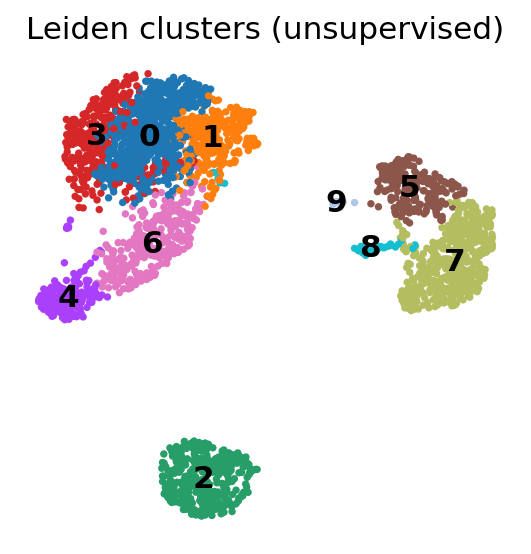

In [94]:
sc.tl.leiden(adata, resolution=0.5, flavor='igraph', n_iterations=2)

sc.pl.umap(
    adata,
    color='leiden',
    legend_loc='on data',
    frameon=False,
    title='Leiden clusters (unsupervised)'
)

---
## Step 7: Cell Type Annotation using Marker Genes

We identify what each cluster is by:
1. Plotting known marker genes on the UMAP
2. Finding which genes are statistically enriched per cluster
3. Cross-referencing with immunology knowledge

| Cell type | Marker gene | Why |
|---|---|---|
| T cells | CD3E | T cell receptor complex |
| CD4+ T cells | CD4 | Helper T cells |
| CD8+ T cells | CD8A | Cytotoxic T cells |
| B cells | CD19, MS4A1 | B cell surface markers |
| NK cells | GNLY, NKG7 | NK cell granule proteins |
| Monocytes | CD14, LYZ | Classical monocytes |

Plotting markers: ['CD3E', 'CD4', 'CD8A', 'CD19', 'MS4A1', 'GNLY', 'CD14', 'LYZ']


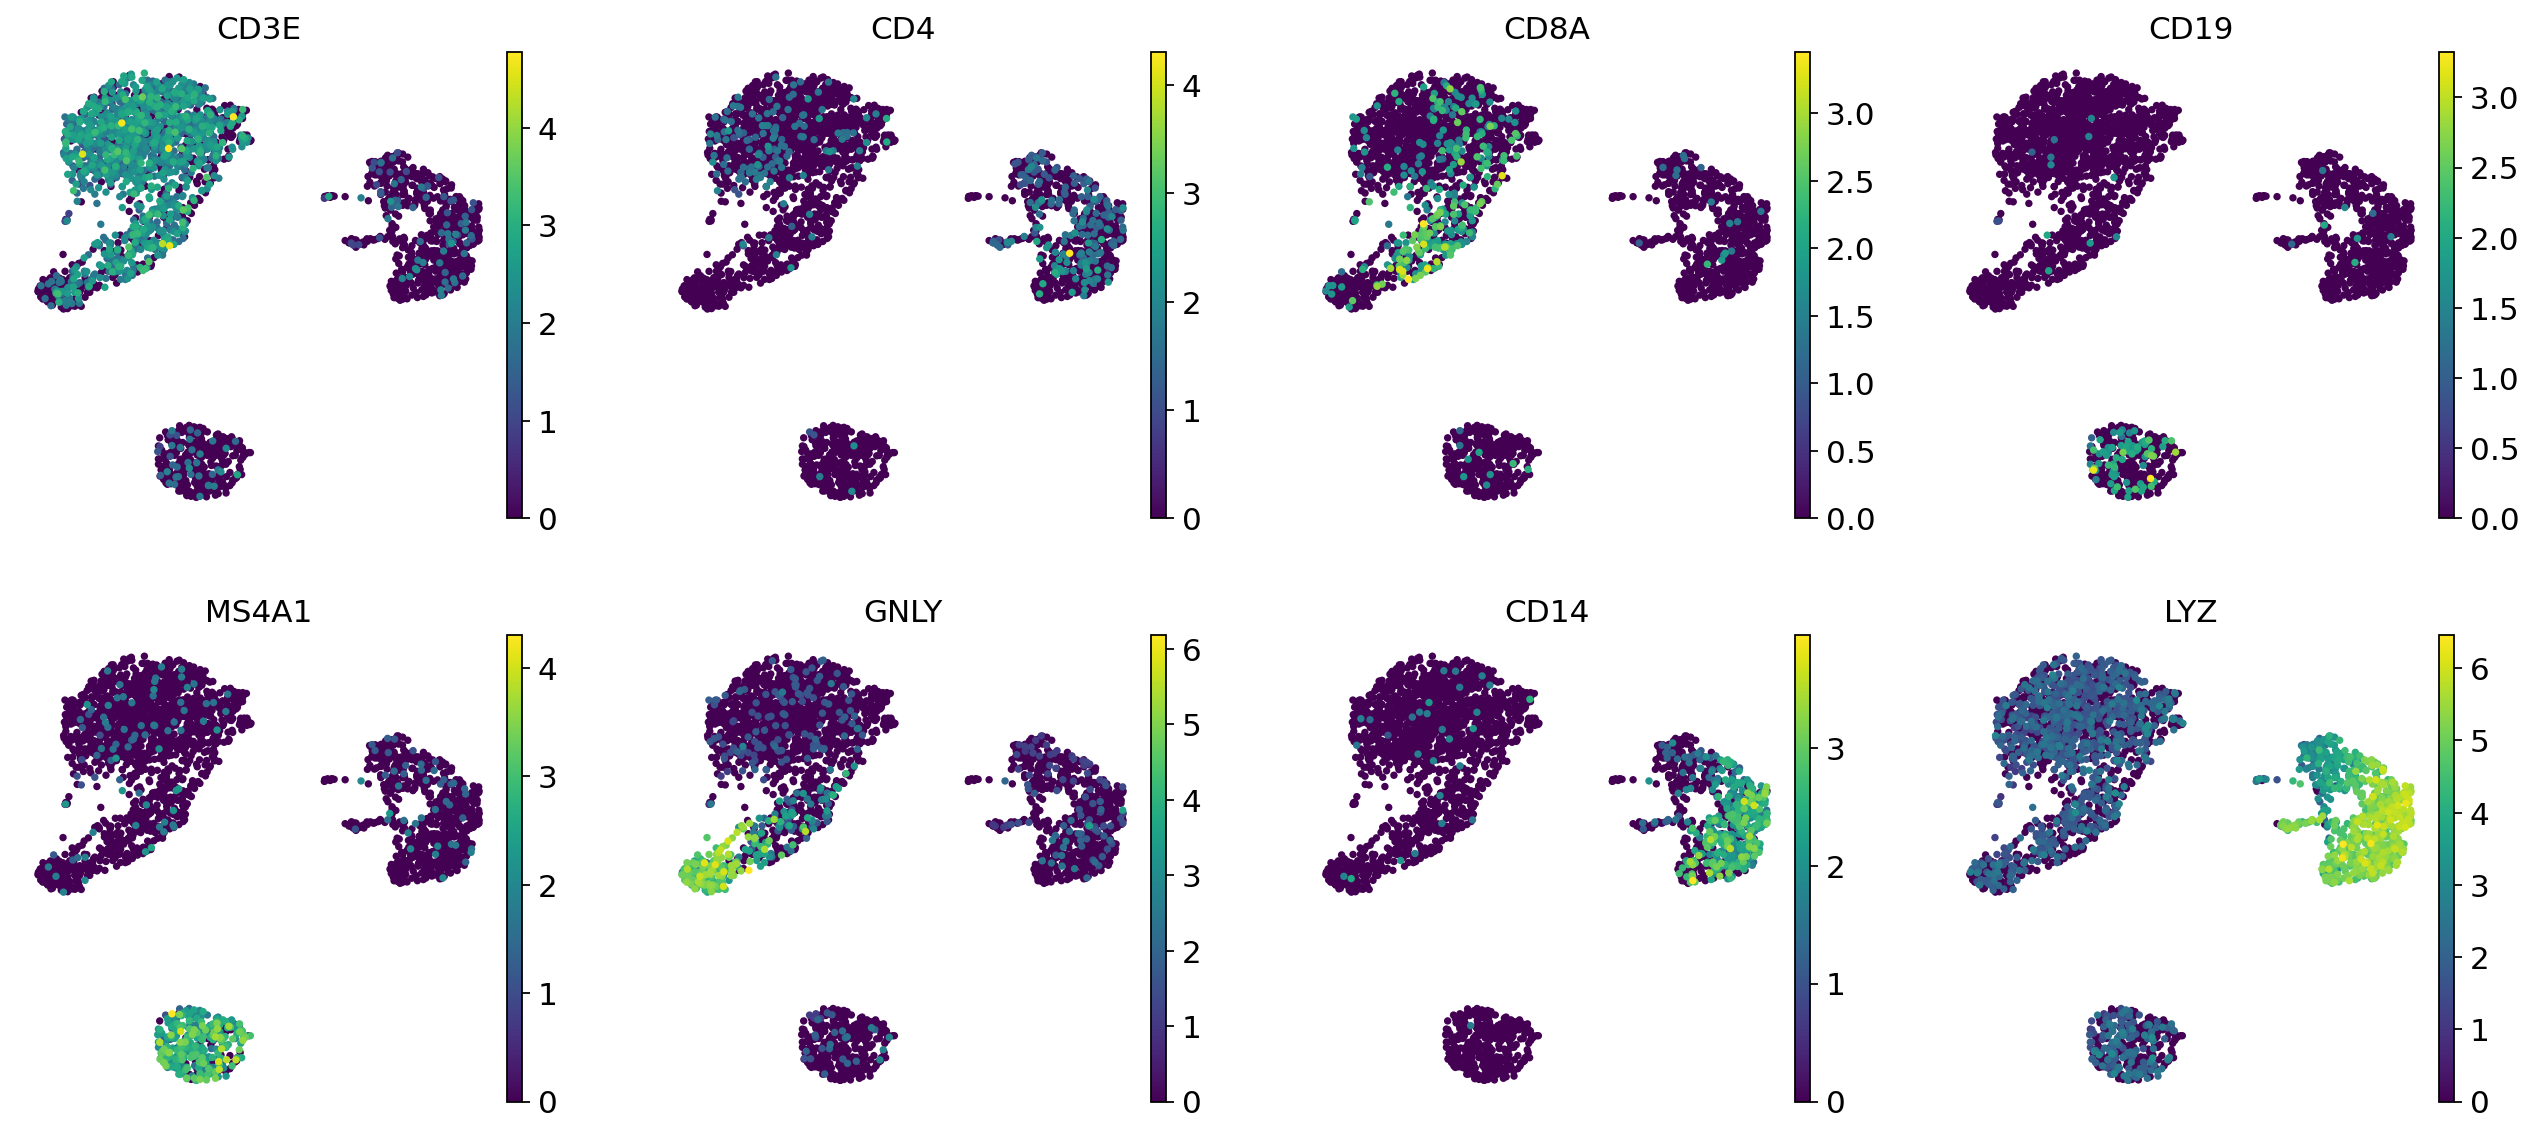

In [95]:
# Plot marker gene expression on UMAP
# High expression (yellow) = that gene is active in those cells

available_markers = [g for g in marker_genes if g in adata.raw.var_names]
print('Plotting markers:', available_markers)

sc.pl.umap(
    adata,
    color=available_markers,
    use_raw=True,
    ncols=4,
    frameon=False
)

`groupby='leiden'`: To use the unsupervised clustering labels as the ground-truth groupings. For each cluster (e.g., Cluster 0), the algorithm splits the entire dataset into two groups: cells inside Cluster 0 versus every single other cell in the dataset combined.


`method='wilcoxon'`: Mann-Whitney U test; a non-parametric statistical test, meaning it makes no assumptions about a normal bell-curve distribution.
  * Single-cell data is heavily zero-inflated and highly skewed. If we use a standard t-test, the rare cells with massive extreme counts would heavily distort the mean, generating false positives. The Wilcoxon test converts absolute expression values into simple ranks, finding genes that are consistently shifted higher in the target cluster regardless of extreme outliers.   

`sharey=False`: allows the vertical Y-axis (the expression score or log-fold change) to scale independently for each cluster's subplot.
  * Some cell types are driven by highly explosive marker genes (like structural or ribosomal genes) with massive expression changes, while other cell types (like regulatory T cells) are defined by subtle shifts in transcription factors. If we set sharey=True, a cluster with a massive scaling factor would squish all the other subplots down into flat, unreadable lines.


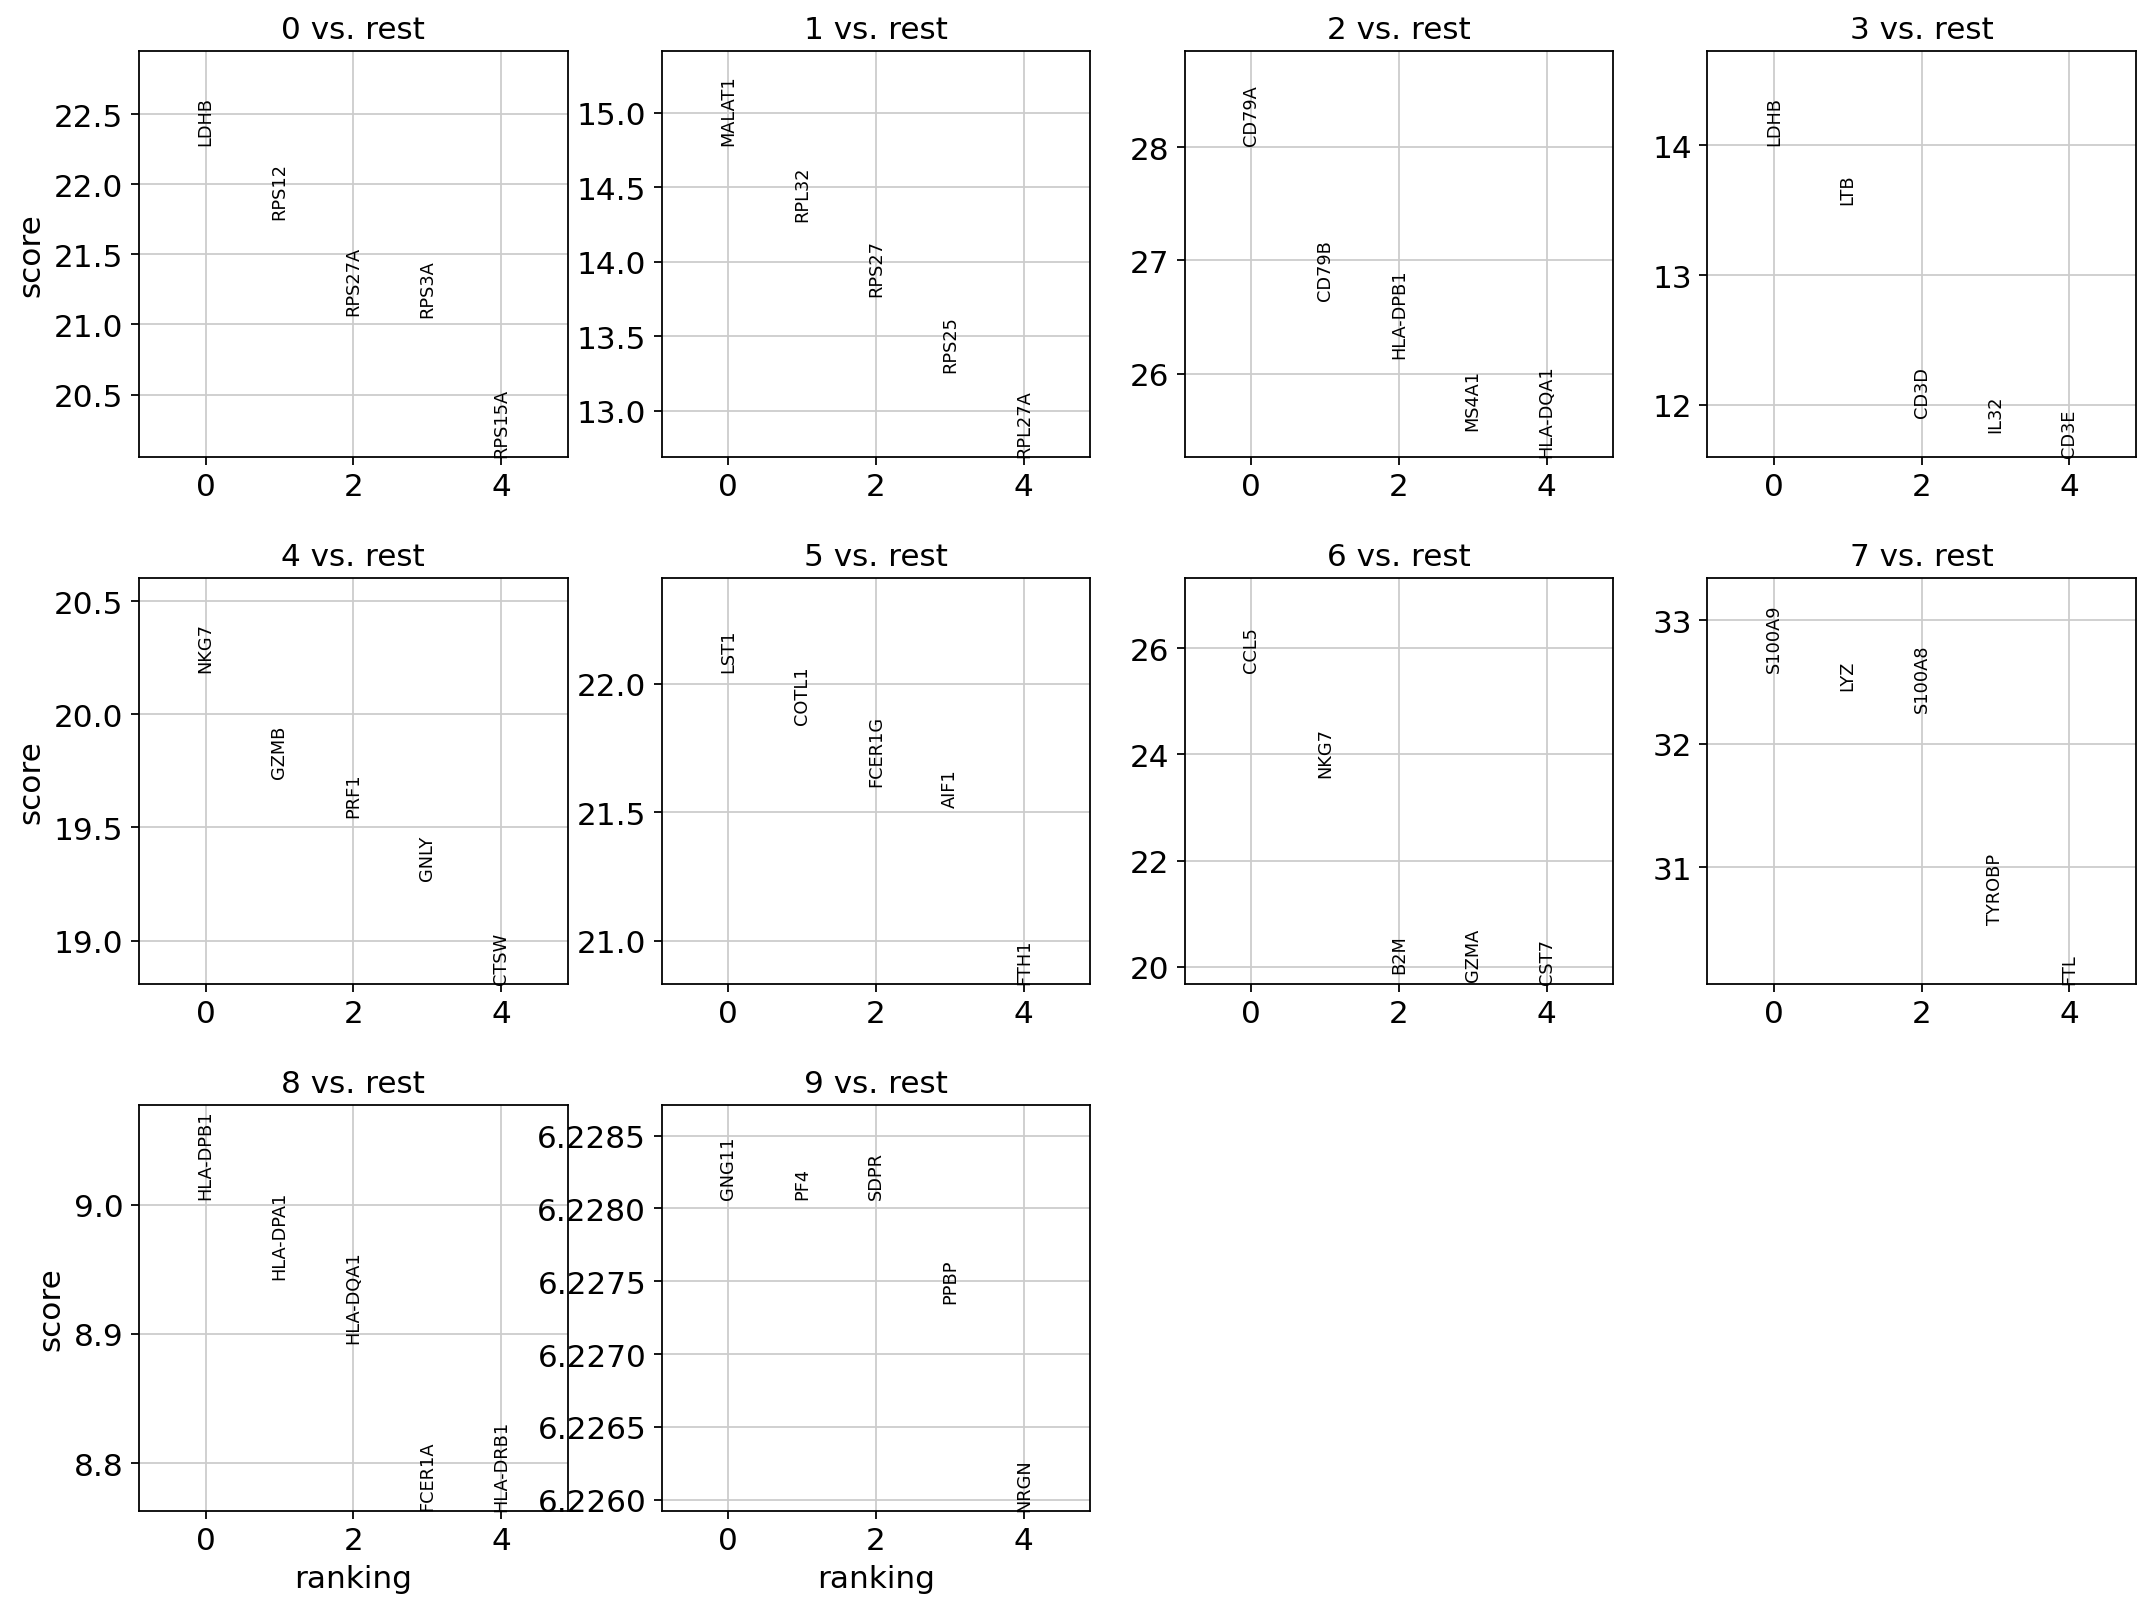

In [96]:
# Compute marker genes per cluster automatically
# Wilcoxon rank-sum test: is this gene significantly higher in cluster X vs all other clusters?


# Differential Expression (DE) analysis, specifically a "one-versus-rest" comparison
# Hunting for the genetic fingerprints that define each cluster

sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

### Reading the plots:
The height of the bars or points indicates how strongly that gene distinguishes that cluster from the background.

Just because a gene is highly ranked in Cluster 0 does not mean it is the only cluster expressing it. It simply means it is significantly more active here than the average of the rest of the dataset.

Take these top gene names and cross-reference them with established immunology lit for annotation.

The Leiden algorithm is entirely unsupervised; it does not know or care how many cell types we are expecting to find. No one-to-one reltionship between gene markers and Wilcoxon plots!!

In [97]:
print(adata.obs['leiden'].value_counts())

leiden
0    607
7    449
2    349
6    317
3    295
1    268
5    201
4    160
8     39
9     13
Name: count, dtype: int64


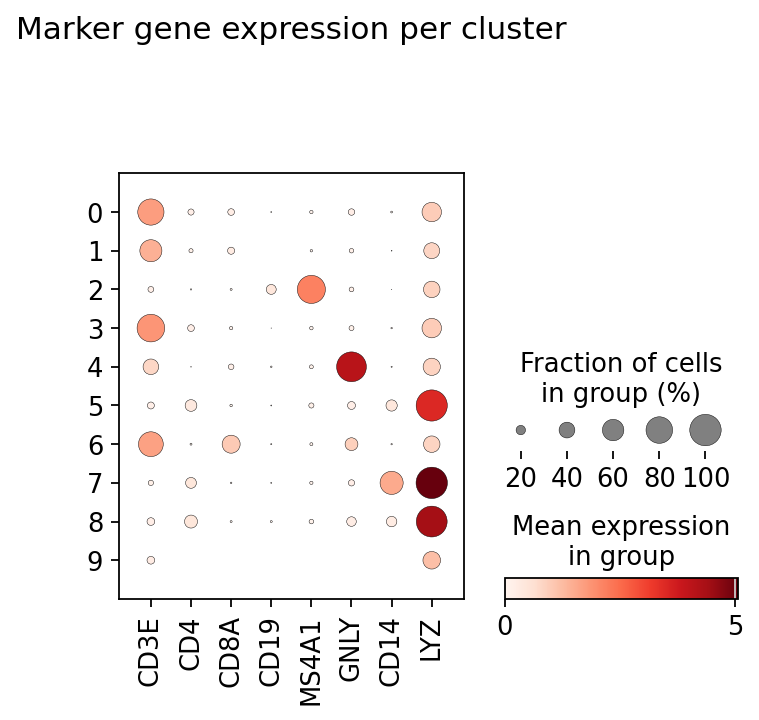

In [98]:
# Dotplot
# X = clusters, Y = marker genes
# Dot size = % of cells in cluster expressing the gene
# Dot colour = mean expression level

sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby='leiden',
    use_raw=True,
    title='Marker gene expression per cluster'
)

### Reading the dotplot
Dot Size: The percentage of cells within that cluster that are expressing the gene. A tiny dot means only a few cells have it; a massive dot means nearly every cell has it.

Dot Colour: The actual intensity of the expression. Pale orange means low expression; dark, heavy red means the gene is being pumped out at massive volumes.

The Biological Annotation:

1. The B Cells (Cluster 2) - A massive, bright red dot for MS4A1 and a smaller one for CD19. This is the classic, indisputable signature of B cells.

2. The NK Cells (Cluster 4) - A massive, dark red dot for GNLY (Granulysin).

3. The T Cells (Clusters 0, 1, 3, and 6) -
Clusters 0, 1, and 3 all show strong, distinct expression of CD3E but lack CD8A. These are likely the CD4+ Helper T cells.
Cluster 6 shows both CD3E and a distinct dot for CD8A, identifying it clearly as the CD8+ Cytotoxic T cell group.

4. The Monocyte Expansion (Clusters 5, 7, and 8) - Cluster 7 shows strong, dark red expression for both CD14 and LYZ. These are the classic, highly active Monocytes.
Clusters 5 and 8 show massive, dark red LYZ expression but lack CD14. These are the non-classical Monocytes or closely related myeloid cells.

5. The Other/Unknown Group (Cluster 9) - Because it does not express T, B, NK, or Monocyte markers, it is a different cell type entirely. In PBMC (Peripheral Blood Mononuclear Cells) datasets, a small blank cluster like this is almost always Platelets or Dendritic Cells.

In [99]:
# Assign cell type labels to clusters based on the dotplot above

# First let's see how many clusters we have
print('Clusters found:', sorted(adata.obs['leiden'].unique()))

Clusters found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


Unmapped cells: 0


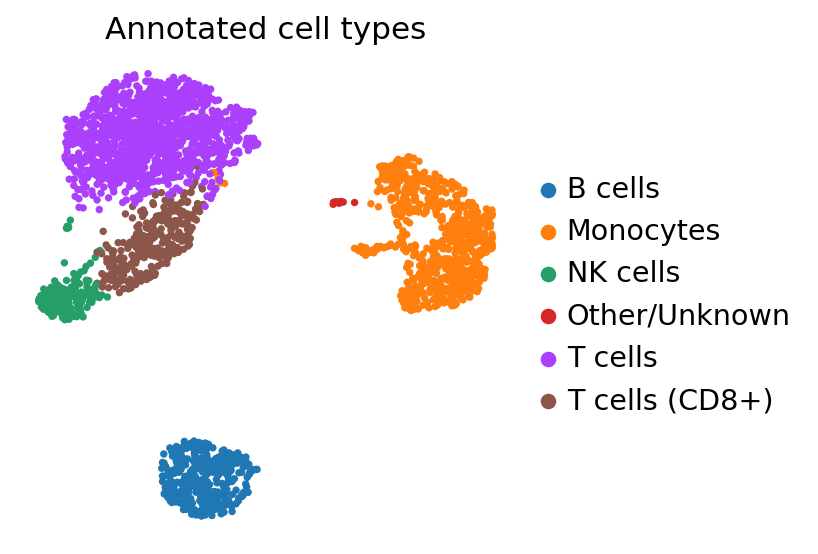

In [100]:
# Map cluster numbers to cell type names
# The mapping depends on what clusters the run produced

# The biological map based on the dot plot
cell_type_map = {
    '0': 'T cells',
    '1': 'T cells',
    '2': 'B cells',          # MS4A1+
    '3': 'T cells',
    '4': 'NK cells',         # GNLY+
    '5': 'Monocytes',        # LYZ+
    '6': 'T cells (CD8+)',   # CD3E+ / CD8A+
    '7': 'Monocytes',        # LYZ+ / CD14+ (Highly active)
    '8': 'Monocytes',        # LYZ+
    '9': 'Other/Unknown'     # Blank (Platelets/DCs)
}


# Apply the map to create the new metadata column
adata.obs['cell_type'] = adata.obs['leiden'].astype(str).map(cell_type_map)


# Verify that no cells were lost to NaN
print("Unmapped cells:", adata.obs['cell_type'].isna().sum())


sc.pl.umap(
    adata,
    color='cell_type',
    # legend_loc='on data',
    title='Annotated cell types',
    frameon=False
)

---
## Step 8: Differential Analysis

We have CKD patients and healthy controls. The biological questions are:

1. **Are any immune populations expanded or contracted in CKD?** (cell composition analysis)
2. **Within a given cell type, are genes expressed differently in CKD?** (differential expression)

The second question is how we find drug targets.

We simulate this with a fake condition label:

In [101]:
# Question 1: Are cell type proportions different between conditions?

proportions = (
    adata.obs
    .groupby(['condition', 'cell_type'])
    .size()
    .unstack(fill_value=0)
    .pipe(lambda df: df.div(df.sum(axis=1), axis=0) * 100)
)

print('Cell type proportions (%) per condition:')
print(proportions.round(1))

Cell type proportions (%) per condition:
cell_type  B cells  Monocytes  NK cells  Other/Unknown  T cells  \
condition                                                         
CKD           13.3       26.2       5.7            0.5     42.2   
Healthy       12.6       24.9       6.2            0.4     44.5   

cell_type  T cells (CD8+)  
condition                  
CKD                  12.1  
Healthy              11.4  


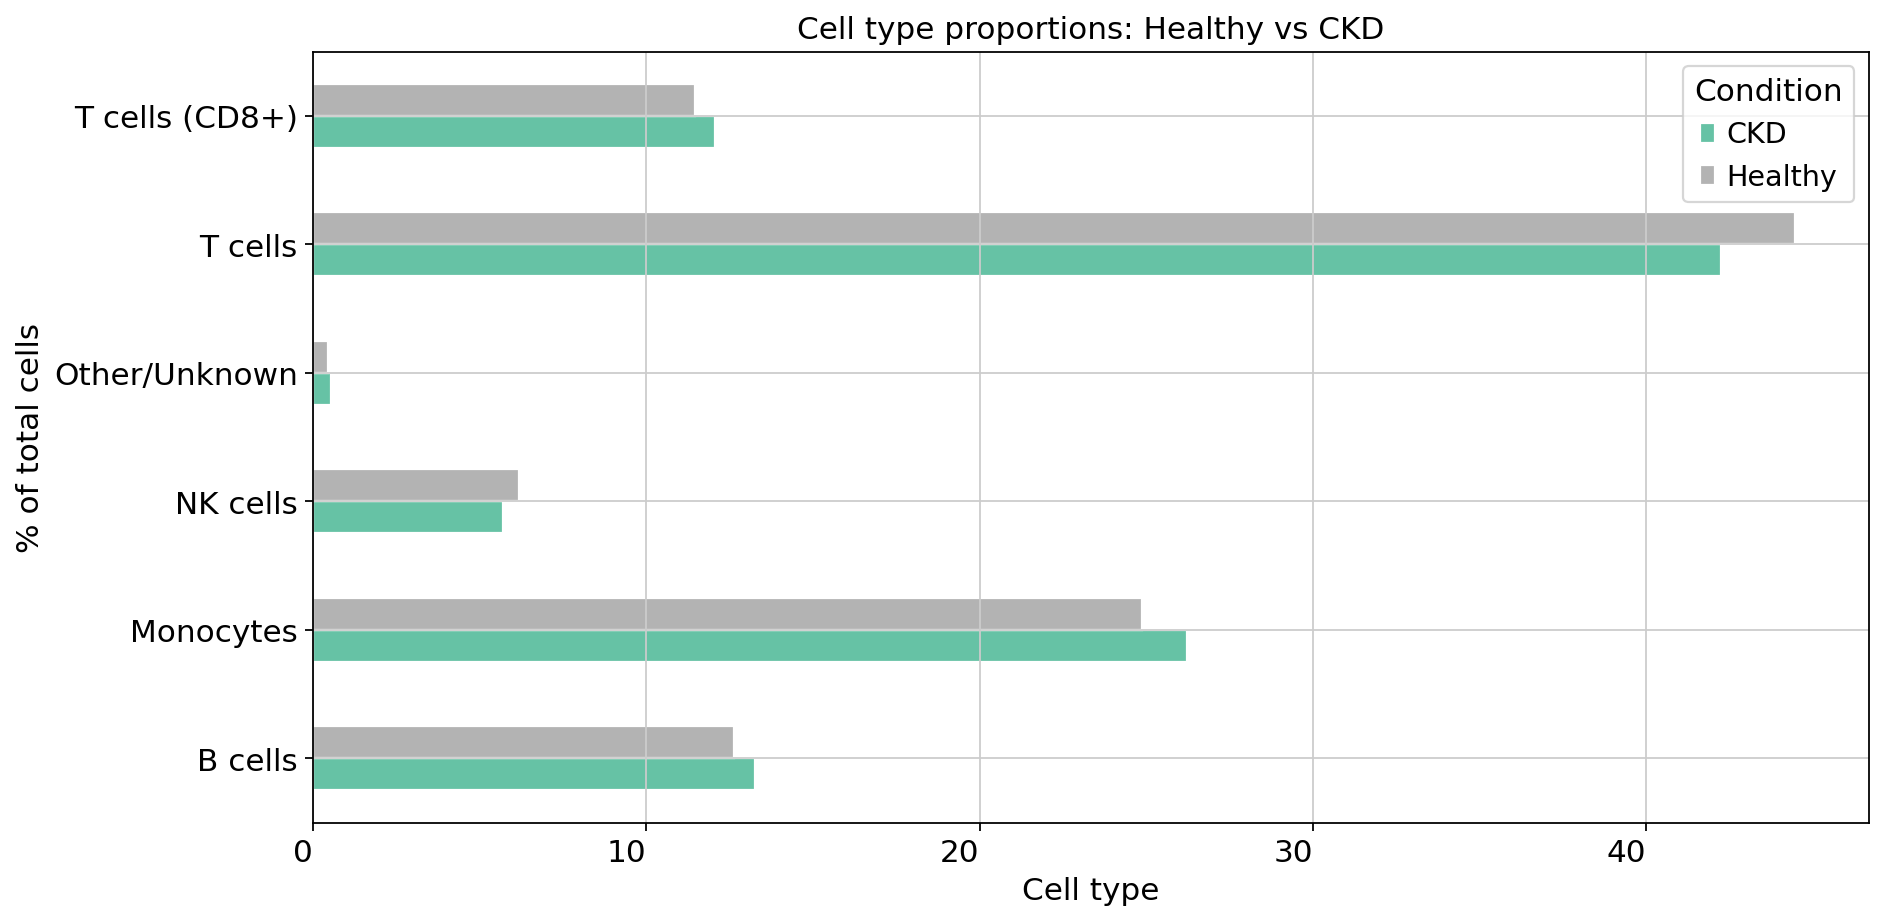

This observation would become a hypothesis that needs to be tested in the wet lab.


In [102]:
# Visualise
fig, ax = plt.subplots(figsize=(12, 6))

proportions.T.plot(
    kind='barh',
    ax=ax,
    colormap='Set2',
    edgecolor='white'
)

ax.set_xlabel('Cell type')
ax.set_ylabel('% of total cells')
ax.set_title('Cell type proportions: Healthy vs CKD')
ax.legend(title='Condition')
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

print("This observation would become a hypothesis that needs to be tested in the wet lab.")

In [103]:
# Question 2: Which genes are differently expressed in CKD vs Healthy?
# This is the direct path to identifying drug targets

if adata.n_obs > 10:  # need enough cells to test
    sc.tl.rank_genes_groups(
        adata,
        groupby='condition',
        method='wilcoxon',
        reference='Healthy',
        layer='normalised',
        use_raw=False
    )

    de_results = sc.get.rank_genes_groups_df(adata, group='CKD')

    # Filter for statistical significance before sorting
    significant_genes = de_results[de_results['pvals_adj'] < 0.05]


    print('\nTop genes upregulated in CKD vs Healthy:')
    print(significant_genes.head(10)[['names', 'scores', 'pvals_adj', 'logfoldchanges']].to_string())
    print('\nThese genes are candidates for oligonucleotide drug targets.')
else:
    print('Not enough cells in this semi-synthetic sample for DE testing.')


Top genes upregulated in CKD vs Healthy:
         names     scores      pvals_adj  logfoldchanges
0          TNF  44.897636   0.000000e+00       10.239047
1         CCL2  44.797985   0.000000e+00       11.653729
2         IL1B  44.383900   0.000000e+00        7.458151
13712  HLA-DRA -18.584799   1.170077e-73       -3.252073
13713     CD74 -31.016680  1.101203e-207       -4.029348

These genes are candidates for oligonucleotide drug targets.


In [104]:
# Question 2: Within monocytes, which genes are differently expressed in CKD vs Healthy?
# This is the direct path to identifying drug targets

adata_mono = adata[adata.obs['cell_type'] == 'Monocytes'].copy()
print(f'Monocytes: {adata_mono.n_obs} cells ({adata_mono.obs["condition"].value_counts().to_dict()})')

if adata_mono.n_obs > 10:  # need enough cells to test
    sc.tl.rank_genes_groups(
        adata_mono,
        groupby='condition',
        method='wilcoxon',
        reference='Healthy',
        layer='normalised',    # Because we scaled adata.X to run the PCA, we have to run DE on the background layer we saved previousely.
        use_raw=False
    )

    de_results = sc.get.rank_genes_groups_df(adata_mono, group='CKD')

    # Filter for statistical significance before sorting
    significant_genes = de_results[de_results['pvals_adj'] < 0.05]


    print('\n' + '='*60 + '\n')


    # Isolate Upregulated Genes (Positive log-fold change, sorted descending)
    significant_genes = significant_genes.sort_values('logfoldchanges', ascending=False).head(10)
    upregulated_genes = significant_genes[significant_genes['logfoldchanges'] > 0]

    print('Top 10 genes UPREGULATED in CKD monocytes vs Healthy:')
    print(upregulated_genes[['names', 'scores', 'pvals_adj', 'logfoldchanges']].to_string())

    print('\n' + '='*60 + '\n')

    # Isolate Downregulated Genes (Negative log-fold change, sorted ascending)
    significant_genes = significant_genes.sort_values('logfoldchanges', ascending=True).head(10)
    downregulated_genes = significant_genes[significant_genes['logfoldchanges'] < 0]
    print('Top 10 genes DOWNREGULATED in CKD monocytes vs Healthy:')
    print(downregulated_genes[['names', 'scores', 'pvals_adj', 'logfoldchanges']].to_string())
    print('\n' + '='*60 + '\n')


else:
    print('Not enough monocytes in this sample for DE testing.')



Monocytes: 689 cells ({'CKD': 350, 'Healthy': 339})


Top 10 genes UPREGULATED in CKD monocytes vs Healthy:
  names     scores      pvals_adj  logfoldchanges
0   TNF  22.706636  5.282941e-110        9.878399
1  CCL2  22.630449  1.490579e-109        9.459433
2  IL1B  21.600956  8.042535e-100        5.309673


Top 10 genes DOWNREGULATED in CKD monocytes vs Healthy:
         names     scores     pvals_adj  logfoldchanges
13712  HLA-DRA -20.318016  2.443991e-88       -4.652973
13713     CD74 -21.050797  7.709606e-95       -4.524301




---
## Step 9: Save the work

In [105]:
# Save directly into the cloned repo
adata.write('/content/scRNA-to-Clinic/pbmc_processed.h5ad')
print('pbmc_processed.h5ad is the input to Module 3 (multi-omics integration).')

This file is the input to Module 3 (multi-omics integration).


In [106]:
size_mb = os.path.getsize('/content/scRNA-to-Clinic/pbmc_processed.h5ad') / 1e6
print(f'File size: {size_mb:.1f} MB')

File size: 362.9 MB


In [116]:
# Large file! Don't git add it — add to .gitignore instead
with open('/content/scRNA-to-Clinic/.gitignore', 'a') as f:
    f.write('\n*.h5ad\n')

!git add {PARENT_DIR}/.gitignore
# !git add {PARENT_DIR}/pbmc_processed.h5ad
!git commit -m "Add .gitignore"
!git push origin main

[main 6c564e2] Add .gitignore
 1 file changed, 2 insertions(+)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 286 bytes | 286.00 KiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/dyarparvar/scRNA-to-Clinic.git
   6075017..6c564e2  main -> main


---

## Exercises

**1. Change the clustering resolution**

Re-run `sc.tl.leiden(adata, resolution=0.2)` then `sc.tl.leiden(adata, resolution=1.0)`. How does the number of clusters change? Does a higher resolution start splitting cell types that should be together?

**2. Explore a gene manually**

Run:
```python
sc.pl.violin(adata, 'CD14', groupby='cell_type', use_raw=True)
```
What does the violin plot tell us about CD14 expression across cell types?

**3. Change the QC threshold**

What happens if we set `pct_counts_mt < 30` instead of `< 20`? How many more cells do we keep, and why might keeping dying cells be a problem?

**4. Heatmap**

Run:
```python
sc.pl.heatmap(adata, var_names=['CD3E','CD19','CD14','GNLY'], groupby='cell_type', use_raw=True)
```
This is another figure type you'll produce at CG-TIC. What story does it tell?
